In [117]:
from sklearn.datasets import make_regression

# generating data
x, y = make_regression(n_samples=100, n_features=10, noise=1, random_state=42)

# Data analysis

1. plot target $`y`$ against feature $`x_5`$

Text(0, 0.5, 'y')

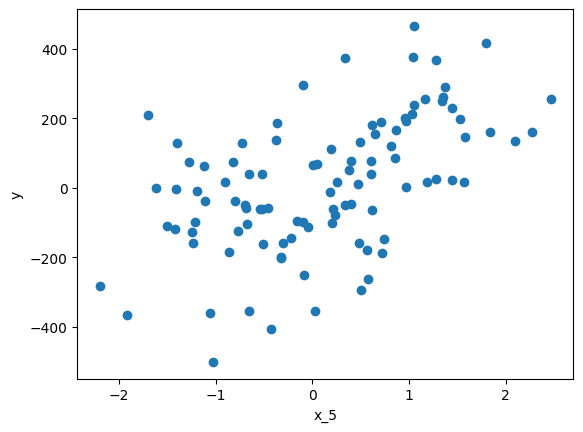

In [128]:
import matplotlib.pyplot as plt

plt.scatter(x[:, 5], y)
plt.xlabel("x_5")
plt.ylabel("y")

# Univariate regression

```math
\hat{y} = w*x+b
```
1. write a function `predict(w: float, x: float, b: float) -> float` that estimates target $`y`$ given feature $`x`$ and parameters $`w`$ and $`b`$ in the case of univariate linear regression
2. write a function `init_parameters() -> tuple[float, float]` that returns random values for parameters $`w`$ and $`b`$
3. apply the model for all the values of feature $`x_5`$ (compute $`\hat{y}`$)
4. add the regression line to the plot of target $`y`$ against feature $`x_5`$

In [152]:
b = -25.0
w = 100.0

def init_parameters() -> tuple[float, float]:
    """ write a function that initializes w and b to random values """
    ...
    return np.random.randn(), np.random.randn()

w, b = init_parameters()

def predict(w: float, x: float, b: float) -> float:
    """ write a function that predicts y given x, w and b in the case of univariate linear regression"""
    ...
    return w * x + b

Text(0, 0.5, 'y')

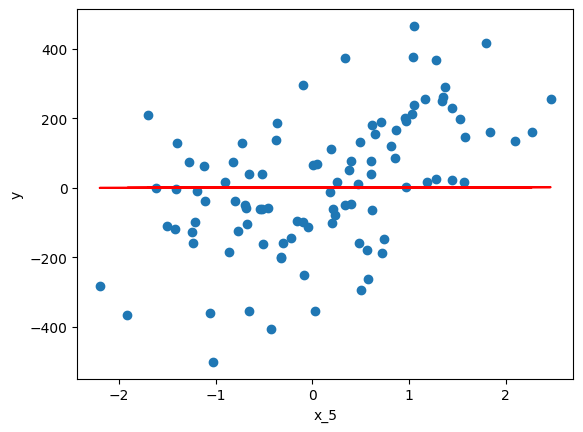

In [153]:
import matplotlib.pyplot as plt
import numpy as np

y_hat = predict(w, x[:, 5], b)

plt.scatter(x[:, 5], y)
plt.plot(x[:, 5], y_hat, color='red')
plt.xlabel("x_5")
plt.ylabel("y")

## Loss function: squared error

```math
L_{w,b}(x) = \frac{1}{2}(\hat{y}-y)^2 = \frac{1}{2}(w*x+b-y)^2
```

1. write a function ``loss_function(y: float, y_hat: float) -> float`` that computes the loss (squared error) between $`y`$ and $`\hat{y}`$

In [154]:
def loss_function(y: float, y_hat: float) -> float:
    """ write a function that computes the squared error between y and y_hat """
    ...
    return 1/2 * (y - y_hat) ** 2

In [155]:
loss_function(y, y_hat)

array([1.25543027e+05, 8.62221543e+04, 2.59858199e+04, 2.06735698e+04,
       1.70381209e+04, 8.16282662e+03, 1.75679728e+04, 2.03914788e+03,
       3.05497441e+02, 4.94296808e+03, 3.18050368e+04, 1.21270723e+03,
       6.67766151e+04, 1.98295374e+04, 3.07106393e+03, 1.11632686e+04,
       1.73203992e+04, 1.17356540e+04, 1.25914798e+04, 3.94876093e+04,
       7.17341146e+03, 6.99151246e+03, 5.24471031e+03, 6.43062183e+03,
       6.67796225e+04, 4.61098966e+03, 7.06900567e+04, 1.33349714e+04,
       1.64191587e+04, 1.13275006e+03, 7.67648381e+03, 3.22263602e+04,
       1.87219579e+03, 8.58598746e+01, 1.07876298e+05, 2.89117778e+00,
       5.12127971e+01, 7.37408806e+02, 1.78236614e+03, 3.24570224e+04,
       2.07600046e+03, 9.99815022e-02, 1.32342326e+02, 1.06427939e+04,
       6.92764008e+04, 1.27494968e+04, 1.59348377e+04, 6.31370202e+04,
       1.37044317e+02, 4.88624609e+03, 7.30368968e+02, 1.97680228e+04,
       1.05659096e+04, 6.51083458e+04, 7.72718728e+02, 1.88221428e+03,
      

## Cost function: mean squared error

```math
J_{w,b} = \frac{1}{2m}\sum{L_{w,b}(x)}
```

1. Write a function `cost_function(y: np.ndarray, y_hat: np.ndarray) -> float` that computes the cost (mean squared error) for a given set of parameters between $`y`$ and $`\hat{y}`$
2. plot the cost function for a large range of $`w`$ values

In [156]:
def cost_function(y: np.ndarray, y_hat: np.ndarray) -> float:
    """ write a function that computes the mean squared error between y and y_hat """
    ...
    return sum(loss_function(y, y_hat)) / len(y)

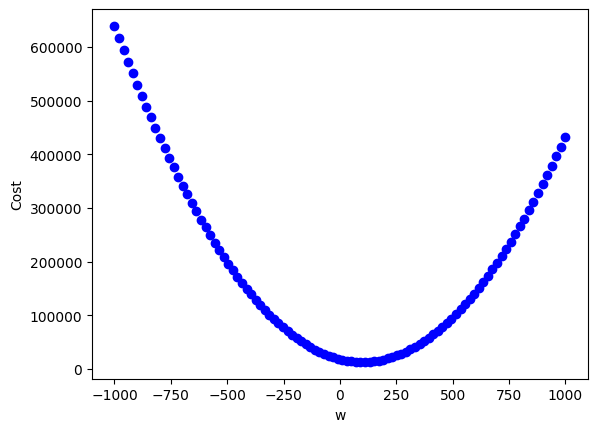

In [157]:
# plot loss function for different values of w
import matplotlib.pyplot as plt

w_range = np.linspace(-1000, 1000, 100)
for w in w_range:
    y_hat = predict(w, x[:, 5], b)
    cost = cost_function(y, y_hat)
    plt.scatter(w, cost, color='blue')
plt.xlabel("w")
plt.ylabel("Cost")
plt.show()

## Gradient Descent Step

```math
w := w - \alpha \frac{\partial J}{\partial w}
```
```math
b := b - \alpha \frac{\partial J}{\partial b}
```

```math
\frac{\partial J}{\partial w} = \frac{1}{m} \sum{(\hat{y}-y)x}
```
```math
\frac{\partial J}{\partial b} = \frac{1}{m} \sum{(\hat{y}-y)}
```

1. write a function `compute_gradient(y: np.ndarray, y_hat: np.ndarray, x: np.ndarray) -> tuple[float, float]` that computes the gradient of the squared error loss with respect to parameters $`w`$ and $`b`$
2. write a function `update_parameters(w: float, b: float, dj_dw: float, dj_db: float, learning_rate: float) -> tuple[float, float]` that updates the parameters $`w`$ and $`b`$ using the gradients of the cost function $`\frac{\partial J}{\partial w}`$ and $`\frac{\partial J}{\partial b}`$ and the learning rate  $`\alpha`$
3. write a function `gradient_descent_one_step(x: np.ndarray, y: np.ndarray, w: float, b: float, learning_rate: float) -> tuple[float, float]` that leverages methods, `predict`, `compute_gradient`, and `update_parameters`, that outputs updated parameters $`w`$ and $`b`$ for one step of gradient descent
3. write a function ``gradient_descent(x: np.ndarray, y: np.ndarray, learning_rate: float, n_iterations: int) -> tuple[float, float]`` that does $`n`$ iterations of gradient descent. Initialize values of parameters $`w`$ and $`b`$ randomly. Make sure to print/plot updated Cost per iteration (learning curve)

Iteration 1/1000, Cost: 18295.59341698973
Iteration 26/1000, Cost: 18033.337361426213
Iteration 51/1000, Cost: 17784.591137204898
Iteration 76/1000, Cost: 17548.65252242136
Iteration 101/1000, Cost: 17324.856092257687
Iteration 126/1000, Cost: 17112.571276894145
Iteration 151/1000, Cost: 16911.20052256601
Iteration 176/1000, Cost: 16720.177550257602
Iteration 201/1000, Cost: 16538.965706821335
Iteration 226/1000, Cost: 16367.056403588811
Iteration 251/1000, Cost: 16203.96763780585
Iteration 276/1000, Cost: 16049.242592473356
Iteration 301/1000, Cost: 15902.448310412843
Iteration 326/1000, Cost: 15763.17443859946
Iteration 351/1000, Cost: 15631.032039017256
Iteration 376/1000, Cost: 15505.652462492275
Iteration 401/1000, Cost: 15386.686282148703
Iteration 426/1000, Cost: 15273.802283312616
Iteration 451/1000, Cost: 15166.686506858538
Iteration 476/1000, Cost: 15065.04134315411
Iteration 501/1000, Cost: 14968.584673910553
Iteration 526/1000, Cost: 14877.04905939104
Iteration 551/1000, Co

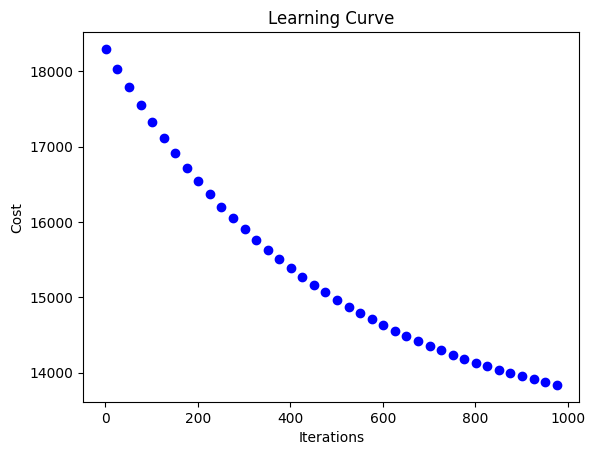

(np.float64(64.1306188269478), np.float64(4.105219950955785))

In [ ]:
def compute_gradient(y: np.ndarray, y_hat: np.ndarray, x: np.ndarray) -> tuple[float, float]:
    """ write a function that computes the gradient of the squared error loss with respect to w and b """
    dw = ((y_hat - y) * x).mean()
    db = (y_hat - y).mean()
    return dw, db

def update_parameters(w: float, b: float, dj_dw: float, dj_db: float, learning_rate: float) -> tuple[float, float]:
    """ write a function that updates the parameters w and b using the gradients dw and db and the learning rate """
    w = w - learning_rate * dj_dw
    b = b - learning_rate * dj_db
    return w, b

def gradient_descent_one_step(x: np.ndarray, y: np.ndarray, w: float, b: float, learning_rate: float) -> tuple[float, float]:
    """ write a function that performs one step of gradient descent to optimize w and b """
    y_hat = predict(w, x, b)
    dw, db = gradient(y, y_hat, x)
    w, b = update_parameters(w, b, dw, db, learning_rate)
    return w, b

def gradient_descent(x: np.ndarray, y: np.ndarray, learning_rate: float, n_iterations: int) -> tuple[float, float]:
    """ write a function that performs gradient descent to optimize w and b """
    w, b = init_parameters()

    # iterating gradient descent
    for i in range(n_iterations):
        
        # doing a single step of gradient descent
        w, b = gradient_descent_one_step(x, y, w, b, learning_rate)

        # computing cost for convergence check
        y_hat = predict(w, x, b)
        current_cost = cost_function(y, y_hat)
        
        # printing cost every 25 iterations
        if i % 25 == 0:
            print(f"Iteration {i+1}/{n_iterations}, Cost: {current_cost}")
            plt.scatter(i+1, current_cost, color='blue')

    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title("Learning Curve")
    plt.show()

    return w, b

gradient_descent(x[:, 5], y, learning_rate=0.001, n_iterations=1000)

# Multivariate regression

```math
\hat{y} = w.x^T+b
```
1. write a function `predict(w: np.ndarray, x: np.ndarray, b: float) -> np.ndarray` that estimates target $`y`$ given features $`x`$ and parameters $`w`$ and $`b`$ in the case of multivariate linear regression
2. apply the model for all the values of feature $`x_5`$ (compute $`\hat{y}`$)
3. for a set of $`w`$ and $`b`$ values, add the regression line to the plot of target $`y`$ against feature $`x_5`$

In [112]:
def predict(w: np.ndarray, x: np.ndarray, b: float) -> np.ndarray:
    """ write a function that predicts y given x, w and b in the case of multivariate linear regression"""
    return np.dot(w, x.T) + b

w = np.random.randn(x.shape[1])
b = 0.0

In [113]:
predict(w, x, b)

array([ 1.96663266,  2.5887053 , -2.1237531 , -1.15658366, -2.55918851,
       -1.7250328 ,  4.71477426,  2.97805642,  0.37154498, -0.41980054,
        0.79756743,  2.05955937,  2.0642697 , -1.47974912, -0.53933105,
        2.39269378, -2.49688056, -1.51046465, -1.75647976, -3.41155725,
       -2.74150899,  1.20305938,  2.82309869, -1.53589212,  0.54321811,
       -2.4934927 ,  0.06558637,  1.93611712, -2.63832461, -3.40237683,
        1.49219563,  0.01003922, -1.39862803, -1.30649075,  0.25603024,
        1.82408655, -1.47650539,  0.23135563,  0.4562389 , -3.06975967,
       -1.93194524,  5.32104374,  0.38272766, -1.7450332 ,  1.02880141,
       -0.05039138,  0.64280271,  2.70124991,  1.32696512,  3.19823938,
        0.23901534, -3.72027356, -0.9112215 , -0.08565675, -0.05264926,
        2.14891569,  1.51565326,  3.71271011, -0.6168276 , -0.03754765,
        1.71981903, -0.31569673,  0.27442477,  1.61450231, -0.6431508 ,
       -0.59308652, -1.81628787, -2.64357088, -1.25954844,  2.13

In [114]:
loss(y, predict(w, x, b))

np.float64(18353.02112424152)

## Gradient Descent Step


```math
w := w - \alpha \frac{\partial J}{\partial w}
```
```math
b := b - \alpha \frac{\partial J}{\partial b}
```

```math
\frac{\partial J}{\partial w} = \frac{1}{m} \sum{x^T.(\hat{y}-y)}
```
```math
\frac{\partial J}{\partial b} = \frac{1}{m} \sum{(\hat{y}-y)}
```

In [115]:
def gradient(y_true: np.ndarray, y_pred: np.ndarray, x: np.ndarray) -> tuple[np.ndarray, float]:
    """ write a function that computes the gradient of the squared error loss with respect to w and b """
    ...
    dw = np.dot(x.T, (y_pred - y_true)) / len(y_true)
    db = np.sum(y_pred - y_true) / len(y_true)
    return dw, db

gradient(y, predict(w, x, b), x)

(array([ -29.51314576,  -56.34350645,   -9.06738026,  -71.18125567,
         -80.62277505, -103.50913874, -104.99422271,   35.63353956,
         -18.14847426,  -68.52644854]),
 np.float64(-11.199329970615638))

Iteration 1/1000, Loss: 14249.706832989916
Iteration 2/1000, Loss: 11126.845828622389
Iteration 3/1000, Loss: 8738.66506661654
Iteration 4/1000, Loss: 6903.151695111778
Iteration 5/1000, Loss: 5485.101209487085
Iteration 6/1000, Loss: 4383.7524961596955
Iteration 7/1000, Loss: 3523.7527473992404
Iteration 8/1000, Loss: 2848.5429423927867
Iteration 9/1000, Loss: 2315.505443596464
Iteration 10/1000, Loss: 1892.396378385367
Iteration 11/1000, Loss: 1554.7163615639072
Iteration 12/1000, Loss: 1283.7677855017841
Iteration 13/1000, Loss: 1065.2154500381466
Iteration 14/1000, Loss: 888.0169870959458
Iteration 15/1000, Loss: 743.6255876612718
Iteration 16/1000, Loss: 625.3937334718452
Iteration 17/1000, Loss: 528.1256936388169
Iteration 18/1000, Loss: 447.7404321285621
Iteration 19/1000, Loss: 381.0167051331728
Iteration 20/1000, Loss: 325.39953450656617
Iteration 21/1000, Loss: 278.8526678217907
Iteration 22/1000, Loss: 239.74561575041088
Iteration 23/1000, Loss: 206.76678404678205
Iteration 

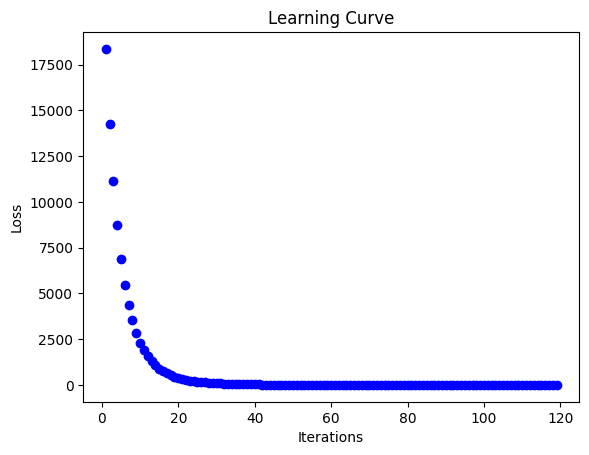

(array([16.92938113, 54.29705894,  5.00404239, 63.57530237, 93.53057194,
        70.65792547, 86.85713402, 10.23045337,  3.23924013, 70.78937453]),
 np.float64(0.11345025370472153))

In [116]:
gradient_descent(x, y, w, b, learning_rate=0.1, n_iterations=1000, eta=1e-3)

# Regularized Gradient Descent 
## Cost function

```math
J_{w,b} = \frac{1}{2m}\sum{L_{w,b}(x)} + \frac{\lambda_2}{2} \sum{w^2}
```

In [97]:
def predict(w: np.ndarray, x: np.ndarray, b: float, l: float) -> np.ndarray:
    """ write a function that predicts y given x, w and b in the case of multivariate linear regression with L2 regularization"""
    return np.dot(w, x.T) + b

def gradient(y_true: np.ndarray, y_pred: np.ndarray, x: np.ndarray, w: np.ndarray, l: float) -> tuple[np.ndarray, float]:
    """ write a function that computes the gradient of the squared error loss with respect to w and b with L2 regularization """
    ...
    dw = (np.dot(x.T, (y_pred - y_true)) + l * w) / len(y_true)
    db = np.sum(y_pred - y_true) / len(y_true)
    return dw, db

